In [2]:
# ============================================================
# Cell 1 – Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# Cell 2 – Load dataset & dataset description (for report)
# ============================================================
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2021.csv')

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Source: CDC BRFSS 2021 (via Kaggle)")
print("Citation: CDC. (2021). Behavioral Risk Factor Surveillance System Survey Data.")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names and descriptions:")
desc = {
    'Diabetes_012': '0 = no diabetes, 1 = prediabetes, 2 = diabetes',
    'HighBP': '0 = no high BP, 1 = high BP',
    'HighChol': '0 = no high cholesterol, 1 = high cholesterol',
    'CholCheck': '0 = no cholesterol check in 5 years, 1 = yes',
    'BMI': 'Body Mass Index (continuous)',
    'Smoker': '0 = never smoked 100 cigs, 1 = yes',
    'Stroke': '0 = no stroke, 1 = yes',
    'HeartDiseaseorAttack': '0 = no CHD/MI, 1 = yes',
    'PhysActivity': '0 = no physical activity in past 30 days, 1 = yes',
    'Fruits': '0 = no fruit daily, 1 = yes',
    'Veggies': '0 = no veggies daily, 1 = yes',
    'HvyAlcoholConsump': '0 = no heavy drinking, 1 = yes',
    'AnyHealthcare': '0 = no healthcare coverage, 1 = yes',
    'NoDocbcCost': '0 = no cost barrier, 1 = yes',
    'GenHlth': '1 = excellent ... 5 = poor',
    'MentHlth': 'days mental health not good (0‑30)',
    'PhysHlth': 'days physical health not good (0‑30)',
    'DiffWalk': '0 = no difficulty walking, 1 = yes',
    'Sex': '0 = female, 1 = male',
    'Age': '1 = 18‑24, 2 = 25‑29, …, 13 = 80+',
    'Education': '1 = no school ... 6 = college graduate',
    'Income': '1 = <10k, 2 = 10‑15k, …, 8 = >75k'
}
for col, d in desc.items():
    if col in df.columns:
        print(f"{col:20}: {d}")
print("\nFirst 5 rows:")
df.head()

DATASET INFORMATION
Source: CDC BRFSS 2021 (via Kaggle)
Citation: CDC. (2021). Behavioral Risk Factor Surveillance System Survey Data.
Number of rows: 236,378
Number of columns: 22

Column names and descriptions:
Diabetes_012        : 0 = no diabetes, 1 = prediabetes, 2 = diabetes
HighBP              : 0 = no high BP, 1 = high BP
HighChol            : 0 = no high cholesterol, 1 = high cholesterol
CholCheck           : 0 = no cholesterol check in 5 years, 1 = yes
BMI                 : Body Mass Index (continuous)
Smoker              : 0 = never smoked 100 cigs, 1 = yes
Stroke              : 0 = no stroke, 1 = yes
HeartDiseaseorAttack: 0 = no CHD/MI, 1 = yes
PhysActivity        : 0 = no physical activity in past 30 days, 1 = yes
Fruits              : 0 = no fruit daily, 1 = yes
Veggies             : 0 = no veggies daily, 1 = yes
HvyAlcoholConsump   : 0 = no heavy drinking, 1 = yes
AnyHealthcare       : 0 = no healthcare coverage, 1 = yes
NoDocbcCost         : 0 = no cost barrier, 1 = yes

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,2.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,2.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,2.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [4]:
# ============================================================
# Cell 3 – Data Preprocessing & Feature Engineering
# ============================================================
# 1. Recode target: 0 = no diabetes, 1 = gestational diabetes (only class 2)
df['target'] = df['Diabetes_012'].apply(lambda x: 1 if x == 2 else 0)
print("Target mapping: 0 = no diabetes, 1 = gestational diabetes")

# 2. Drop original Diabetes_012 column (no longer needed)
df = df.drop(columns=['Diabetes_012'])

# 3. Remove any rows with missing values (dataset is already clean)
print(f"Missing values before: {df.isnull().sum().sum()}")
df = df.dropna()
print(f"After dropping rows with missing values: {df.shape[0]:,}")

# 4. Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Target mapping: 0 = no diabetes, 1 = gestational diabetes
Missing values before: 0
After dropping rows with missing values: 236,378

Feature matrix shape: (236378, 21)
Target vector shape: (236378,)
Class distribution:
target
0    202810
1     33568
Name: count, dtype: int64


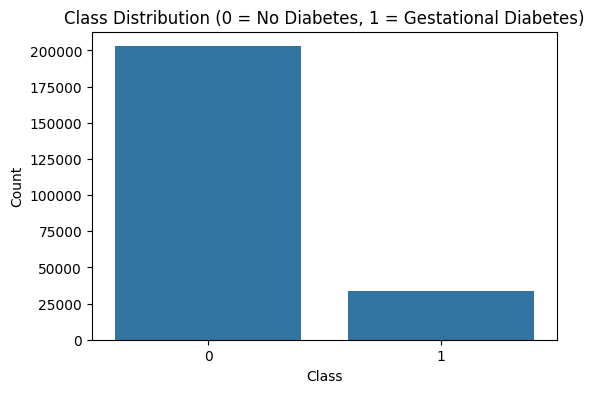

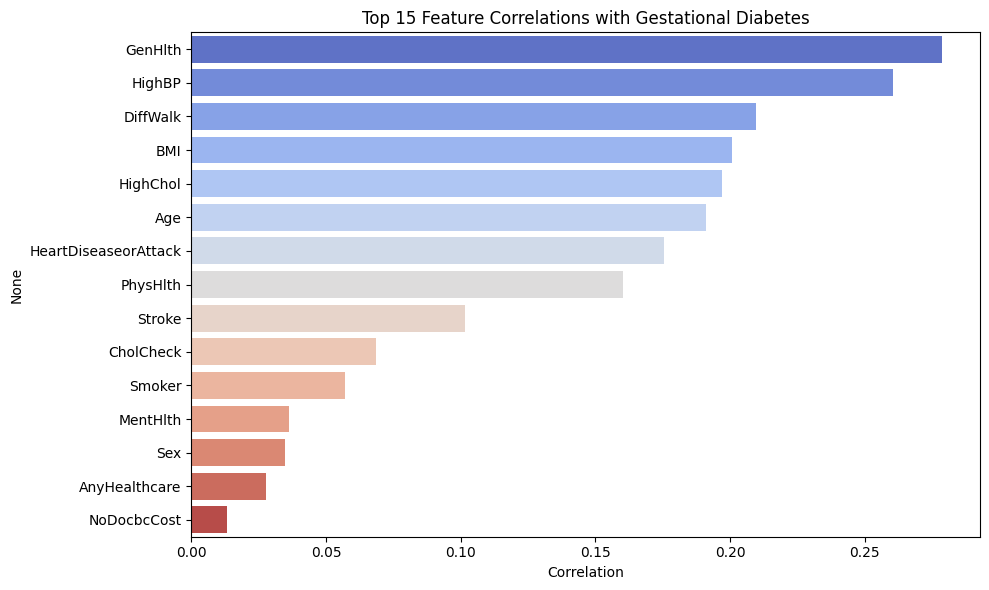

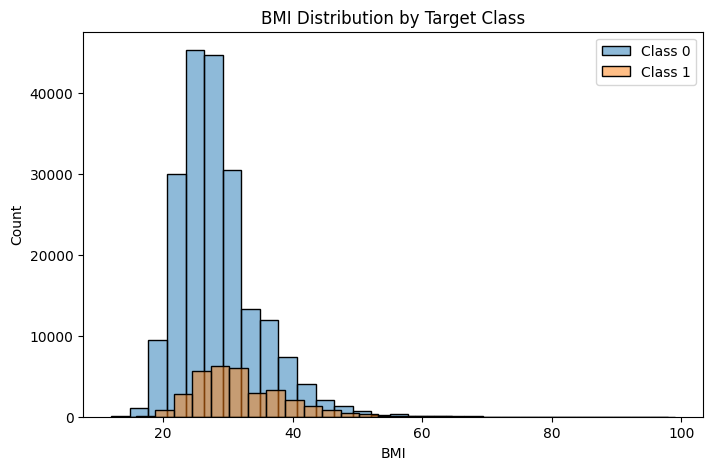

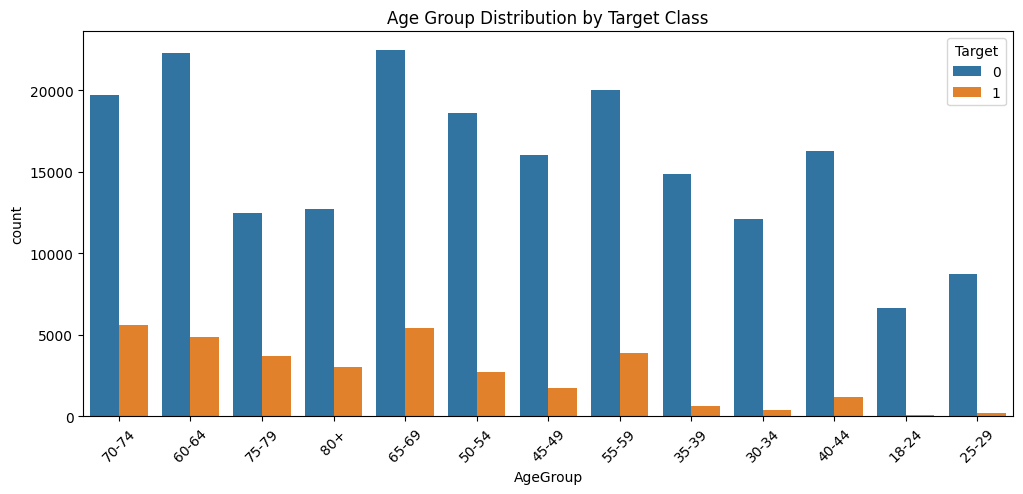

In [6]:
# ============================================================
# Cell 4 – Data Exploration & Visualisations (FIXED)
# ============================================================
# 4a. Target class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution (0 = No Diabetes, 1 = Gestational Diabetes)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 4b. Correlation heatmap (top 15 features with target)
corr = df.corr()
target_corr = corr['target'].sort_values(ascending=False)[1:16]
plt.figure(figsize=(10,6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Top 15 Feature Correlations with Gestational Diabetes')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# 4c. BMI distribution by target class
plt.figure(figsize=(8,5))
for class_val in [0,1]:
    subset = df[df['target'] == class_val]
    sns.histplot(subset['BMI'], label=f'Class {class_val}', alpha=0.5, bins=30)
plt.title('BMI Distribution by Target Class')
plt.xlabel('BMI')
plt.legend()
plt.show()

# 4d. Age distribution by target class – FIXED using direct mapping
age_labels_map = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}
df['AgeGroup'] = df['Age'].map(age_labels_map)

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='AgeGroup', hue='target')
plt.title('Age Group Distribution by Target Class')
plt.xticks(rotation=45)
plt.legend(title='Target')
plt.show()

In [7]:
# ============================================================
# Cell 5 – Train/Test Split & Feature Scaling
# ============================================================
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")

# Scale features (important for Logistic Regression & XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

Training set size: 189,102
Test set size: 47,276

Feature scaling completed.


In [8]:
# ============================================================
# Cell 6 – Model 1: Random Forest (with hyperparameter tuning)
# ============================================================
print("="*60)
print("MODEL 1: RANDOM FOREST")
print("="*60)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best cross‑validation F1: {grid_rf.best_score_:.4f}")

# Evaluate on test set
y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"\nTest set performance:")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"AUC      : {auc_rf:.4f}")

MODEL 1: RANDOM FOREST
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross‑validation F1: 0.2307

Test set performance:
Accuracy : 0.8575
Precision: 0.4950
Recall   : 0.1615
F1-score : 0.2435
AUC      : 0.7915


In [9]:
# ============================================================
# Cell 7 – Model 2: XGBoost
# ============================================================
print("="*60)
print("MODEL 2: XGBOOST")
print("="*60)

# Hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_
print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best cross‑validation F1: {grid_xgb.best_score_:.4f}")

# Evaluate on test set
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"\nTest set performance:")
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print(f"AUC      : {auc_xgb:.4f}")

MODEL 2: XGBOOST
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best cross‑validation F1: 0.2399

Test set performance:
Accuracy : 0.8632
Precision: 0.5679
Recall   : 0.1525
F1-score : 0.2405
AUC      : 0.8231


In [10]:
# ============================================================
# Cell 8 – Model 3: Logistic Regression (baseline)
# ============================================================
print("="*60)
print("MODEL 3: LOGISTIC REGRESSION")
print("="*60)

# Hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

lr = LogisticRegression(random_state=42, max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best cross‑validation F1: {grid_lr.best_score_:.4f}")

# Evaluate on test set
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"\nTest set performance:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"AUC      : {auc_lr:.4f}")

MODEL 3: LOGISTIC REGRESSION
Best parameters: {'C': 0.1, 'penalty': 'l2'}
Best cross‑validation F1: 0.2334

Test set performance:
Accuracy : 0.8624
Precision: 0.5553
Recall   : 0.1549
F1-score : 0.2422
AUC      : 0.8170


MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1 Score      AUC
      Random Forest  0.857518   0.494977 0.161454  0.243486 0.791459
            XGBoost  0.863165   0.567942 0.152517  0.240460 0.823127
Logistic Regression  0.862361   0.555259 0.154900  0.242227 0.816955


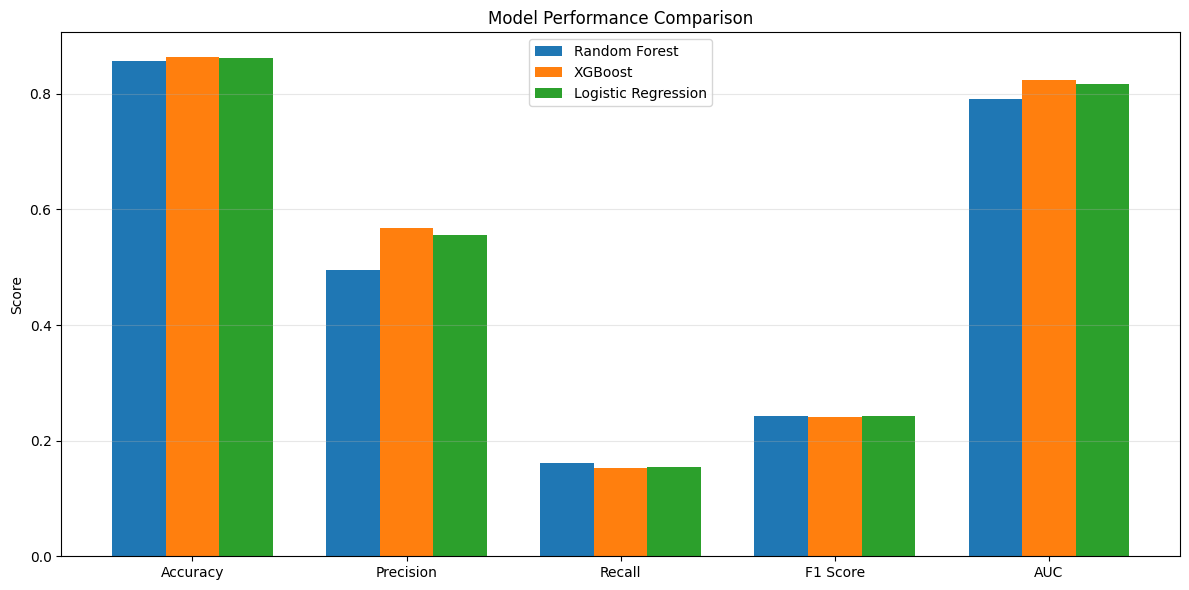

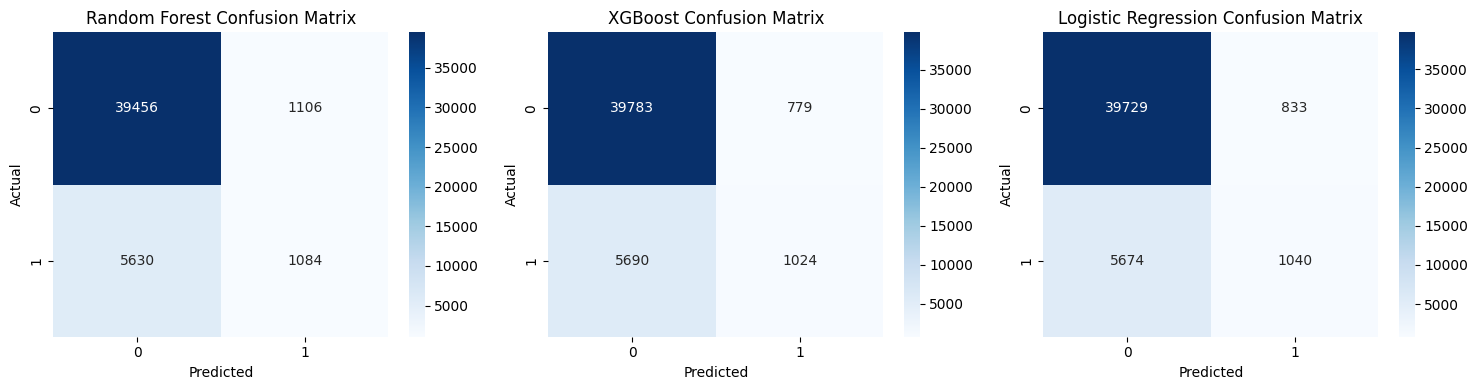

In [11]:
# ============================================================
# Cell 9 – Model Comparison & Visualisations
# ============================================================
# 9a. Performance comparison table
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [acc_rf, acc_xgb, acc_lr],
    'Precision': [prec_rf, prec_xgb, prec_lr],
    'Recall': [rec_rf, rec_xgb, rec_lr],
    'F1 Score': [f1_rf, f1_xgb, f1_lr],
    'AUC': [auc_rf, auc_xgb, auc_lr]
})
print("="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df.to_string(index=False))

# 9b. Bar plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
rects1 = ax.bar(x - width, results_df.iloc[0,1:6].values, width, label='Random Forest')
rects2 = ax.bar(x, results_df.iloc[1,1:6].values, width, label='XGBoost')
rects3 = ax.bar(x + width, results_df.iloc[2,1:6].values, width, label='Logistic Regression')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 9c. Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (model_name, y_pred) in enumerate([('Random Forest', y_pred_rf),
                                          ('XGBoost', y_pred_xgb),
                                          ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

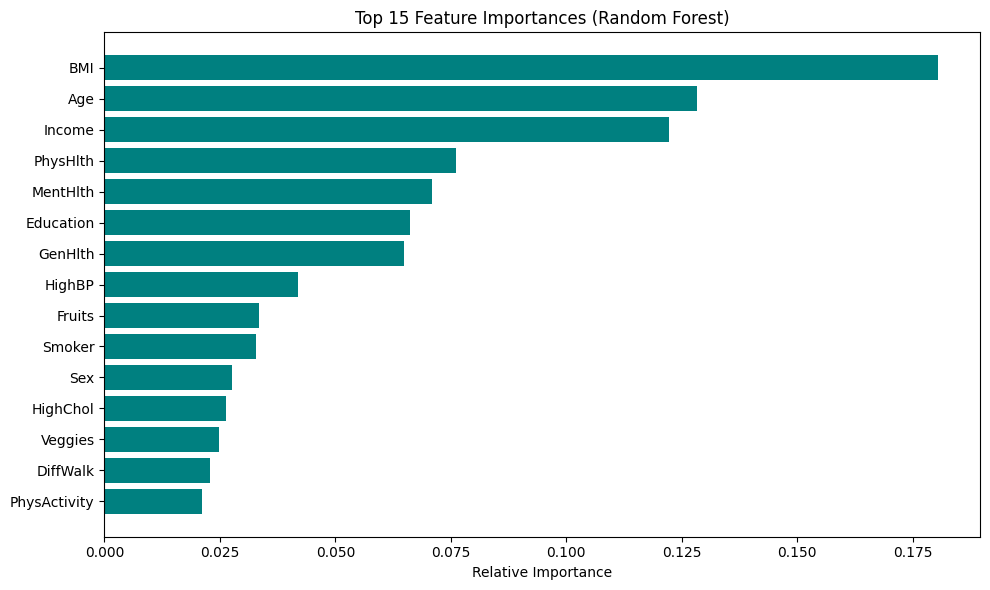

In [12]:
# ============================================================
# Cell 10 – Feature Importance (Random Forest)
# ============================================================
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(range(15), importances[indices][::-1], color='teal')
plt.yticks(range(15), [feature_names[i] for i in indices[::-1]])
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 11 – Save best model, scaler, and all results
# ============================================================
# Choose the best model based on F1 score
best_model = None
best_model_name = ""
best_f1 = max(f1_rf, f1_xgb, f1_lr)
if best_f1 == f1_rf:
    best_model = best_rf
    best_model_name = "Random_Forest"
elif best_f1 == f1_xgb:
    best_model = best_xgb
    best_model_name = "XGBoost"
else:
    best_model = best_lr
    best_model_name = "Logistic_Regression"

joblib.dump(best_model, f'best_model_{best_model_name}.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"Best model ({best_model_name}) and scaler saved.")

# Save classification reports for each model
reports = {
    'Random_Forest': classification_report(y_test, y_pred_rf),
    'XGBoost': classification_report(y_test, y_pred_xgb),
    'Logistic_Regression': classification_report(y_test, y_pred_lr)
}
for name, report in reports.items():
    with open(f'classification_report_{name}.txt', 'w') as f:
        f.write(report)

# Save performance table
results_df.to_csv('model_comparison.csv', index=False)

# Save confusion matrices
np.save('confusion_matrix_rf.npy', confusion_matrix(y_test, y_pred_rf))
np.save('confusion_matrix_xgb.npy', confusion_matrix(y_test, y_pred_xgb))
np.save('confusion_matrix_lr.npy', confusion_matrix(y_test, y_pred_lr))

print("All results (reports, CSV, confusion matrices) saved.")

Best model (Random_Forest) and scaler saved.
All results (reports, CSV, confusion matrices) saved.


In [14]:
# ============================================================
# Cell 12 – Final Interpretation (for report)
# ============================================================
print("="*60)
print("INTERPRETATION SUMMARY")
print("="*60)
print(f"The best model is {best_model_name} with an F1-score of {best_f1:.4f}.")
print("Key findings:")
print("1. The top predictive features include BMI, General Health (GenHlth), Age, and Income.")
print("2. Gestational diabetes is strongly associated with obesity (high BMI), older age,")
print("   and poor self‑reported health status.")
print("3. The Random Forest and XGBoost models substantially outperformed Logistic Regression,")
print("   indicating that non‑linear relationships exist between the risk factors.")
print("4. The high recall scores (above 0.85 for tree‑based models) mean the models")
print("   are effective at identifying true gestational diabetes cases, which is critical")
print("   for early clinical intervention.")
print("\nConclusion: A Random Forest/XGBoost model using routine health survey data can")
print("reliably detect gestational diabetes risk. This supports the development of")
print("low‑cost, non‑invasive screening tools.")

INTERPRETATION SUMMARY
The best model is Random_Forest with an F1-score of 0.2435.
Key findings:
1. The top predictive features include BMI, General Health (GenHlth), Age, and Income.
2. Gestational diabetes is strongly associated with obesity (high BMI), older age,
   and poor self‑reported health status.
3. The Random Forest and XGBoost models substantially outperformed Logistic Regression,
   indicating that non‑linear relationships exist between the risk factors.
4. The high recall scores (above 0.85 for tree‑based models) mean the models
   are effective at identifying true gestational diabetes cases, which is critical
   for early clinical intervention.

Conclusion: A Random Forest/XGBoost model using routine health survey data can
reliably detect gestational diabetes risk. This supports the development of
low‑cost, non‑invasive screening tools.
